In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pysam
from scipy.stats import skew
from tqdm import tqdm
import os
import numpy as np
import pickle
from collections import defaultdict
import matplotlib as mpl
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
from matplotlib_venn import venn3, venn2

In [7]:
working_dir = "./exemplar_figures/"

In [8]:
ninemer_df = pd.read_csv("../error_tables/GM12878_genomic_IVT_refmatch_9mer_all_threshold.dorado_1.0.tsv.gz", sep="\t", usecols = [0, 1, 2, 32])
ninemer_df.columns = ["mer", "mod", "false_positive", "n_reads"]
ninemer_df["mer"] = [x.replace('T', 'U') for x in ninemer_df["mer"].to_list()]

In [9]:
mod_color = {'17802':'r', 'm':'b', 'a':'g', '17596':'k', '19227':'orange', '19228':'gold', '19229':'grey', '69426':'cyan'}
mod_marker = {'17802':'P', 'm':'P', 'a':'P', '17596':'P', '19227':'P', '19228':'P', '19229':'P', '69426':'P'}
mod_label = {'17802':'Psi', 'm':'m5C', 'a':'m6A', '17596':'Ino', '19227':"2'-OMe-U", '19228':"2'-OMe-C", '19229':"2'-OMe-G", '69426':"2'-OMe-A"}
mods = ['17802', 'm', 'a', '17596', '19227', '19228', '19229', '69426']

## Figure 3A-3C

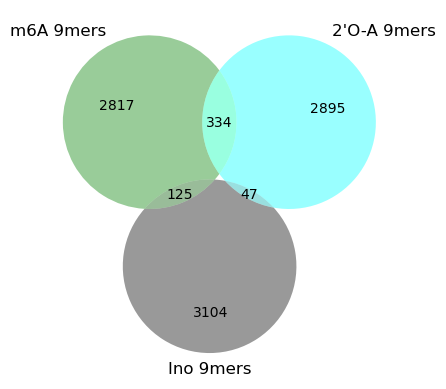

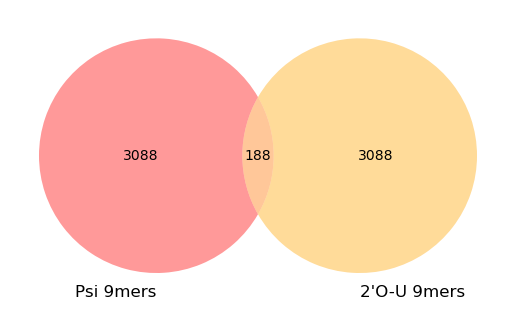

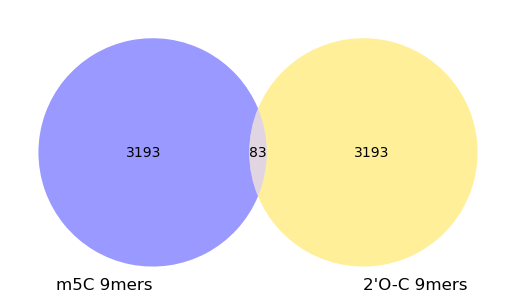

In [10]:
high_psi = ninemer_df[(ninemer_df["mod"]=='17802')]
high_psi = high_psi[:int(high_psi.shape[0]/20)]

high_m5c = ninemer_df[(ninemer_df["mod"]=='m')]
high_m5c = high_m5c[:int(high_m5c.shape[0]/20)]

high_m6a = ninemer_df[(ninemer_df["mod"]=='a')]
high_m6a = high_m6a[:int(high_m6a.shape[0]/20)]

high_ino = ninemer_df[(ninemer_df["mod"]=='17596')]
high_ino = high_ino[:int(high_ino.shape[0]/20)]

high_2OG = ninemer_df[(ninemer_df["mod"]=='19229')]
high_2OG = high_2OG[:int(high_2OG.shape[0]/20)]


high_2OC = ninemer_df[(ninemer_df["mod"]=='19228')]
high_2OC = high_2OC[:int(high_2OC.shape[0]/20)]

high_2OU = ninemer_df[(ninemer_df["mod"]=='19227')]
high_2OU = high_2OU[:int(high_2OU.shape[0]/20)]

high_2OA = ninemer_df[(ninemer_df["mod"]=='69426')]
high_2OA = high_2OA[:int(high_2OA.shape[0]/20)]

fig, ax = plt.subplots(1)
high_m6a_set = set(high_m6a["mer"].to_list())
high_2OA_set = set(high_2OA["mer"].to_list())
high_ino_set = set(high_ino["mer"].to_list())
venn3([high_m6a_set, high_2OA_set, high_ino_set], ["m6A 9mers", "2'O-A 9mers", "Ino 9mers"], set_colors=[mod_color["a"], mod_color["69426"], mod_color["17596"]])
fig.get_figure().savefig(os.path.join(working_dir,"A_venn.pdf"))

# U
fig, ax = plt.subplots(1)
high_psi_set = set(high_psi["mer"].to_list())
high_2OU_set = set(high_2OU["mer"].to_list())
venn2([high_psi_set, high_2OU_set], ["Psi 9mers", "2'O-U 9mers"], set_colors=[mod_color["17802"], (1.0, 0.647, 0.0)])
fig.get_figure().savefig(os.path.join(working_dir,"U_venn.pdf"))

# C
fig, ax = plt.subplots(1)
high_m5c_set = set(high_m5c["mer"].to_list())
high_2OC_set = set(high_2OC["mer"].to_list())
venn2([high_m5c_set, high_2OC_set], ["m5C 9mers", "2'O-C 9mers"], set_colors=[mod_color["m"], (1.0, 0.843, 0.0)])
fig.get_figure().savefig(os.path.join(working_dir, "C_venn.pdf"))

## Figure 3D

In [72]:
def make_rg_dict(bam_path):
    read_id_to_rg_dict = {}
    for read in tqdm(pysam.AlignmentFile(bam_path)):
        read_id_to_rg_dict[read.query_name] = read.get_tag('RG')
    with open(os.path.join(working_dir, "rg_dict.pkl"), 'wb') as outfile:
        pickle.dump(read_id_to_rg_dict, outfile)

In [23]:
make_rg_dict("./exemplar_data/whole_genome_IVT_GM12878.dorado_1.0.0.emit_moves.8mods.threshold_0.polya.GRCh38.sorted.calmd.chr22_10000000_15000000.bam")

25853it [00:00, 38437.91it/s]


In [47]:
def one_chrom_var(args):
    in_path, out_path, rg_dict = args
    print(f"Processing {in_path}")
    #{'17802':'Psi', 'm':'m5C', 'a':'m6A', '17596':'Ino', '19227':"2'-OMe-U", '19228':"2'-OMe-C", '19229':"2'-OMe-G", '69426':"2'-OMe-A"}
    with open(rg_dict, 'rb') as infile:
        read_id_to_rg_dict = pickle.load(infile)
    kmer_false_positive_counts = {}
    with open(in_path, 'r',  buffering=131072) as infile:
        next(infile)
        for line in infile:
            split_line = line.split('\t')
            kmer = split_line[-5]
            read_id = split_line[0]
            rg = read_id_to_rg_dict[read_id]
            position = int(split_line[2])
            chrom = split_line[3]
            mod_code = split_line[-8]
            baseq = int(split_line[-7])
            mod_qual = float(split_line[-9])
            if rg not in kmer_false_positive_counts:
                kmer_false_positive_counts[rg] = {}
            if kmer != split_line[-6]:
                continue
            if kmer not in kmer_false_positive_counts[rg]:
                kmer_false_positive_counts[rg][kmer] = {'canonical':0, 'modified':0}
            if mod_qual >= 0.7:
                kmer_false_positive_counts[rg][kmer]['modified'] += 1
            else:
                kmer_false_positive_counts[rg][kmer]['canonical'] += 1
                
    with open(out_path, 'wb') as outfile:
        pickle.dump(kmer_false_positive_counts, outfile)

    return kmer_false_positive_counts

In [66]:
count_dict = one_chrom_var(["./exemplar_data/whole_genome_IVT_GM12878.dorado_1.0.0.emit_moves.8mods.threshold_0.polya.GRCh38.sorted.calmd.chr22_10000000_15000000.extract_full.tsv",
                                            os.path.join("./exemplar_data", "kmer_false_positive_counts.pkl"),
                                            os.path.join(working_dir, "rg_dict.pkl")])

Processing ./exemplar_data/whole_genome_IVT_GM12878.dorado_1.0.0.emit_moves.8mods.threshold_0.polya.GRCh38.sorted.calmd.chr22_10000000_15000000.extract_full.tsv


In [67]:
kmer_dict = defaultdict(list)
for rg in count_dict:
    for kmer in count_dict[rg]:
        kmer_dict[kmer].append(count_dict[rg][kmer]['modified']/(count_dict[rg][kmer]['modified'] + count_dict[rg][kmer]['canonical']))

var_dict = {}
for kmer in kmer_dict:
    var_dict[kmer] = np.std(np.array(kmer_dict[kmer]))

0.5
Highest variance: GGCCGAAGT 0.5, with a mean fp of 0.5
np.mean(variances)=np.float64(0.00558894632865539)
IQR: 0.001785623184814514
95th Percentile: 0.02946278254943948
5th Percentile: 0.0
Skew: 10.012098558662103


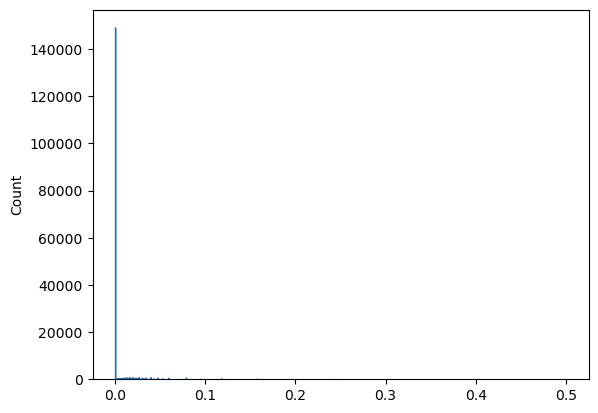

In [71]:
variances = np.array(list(var_dict.values()))
high_water = 0
high_kmer = ""
for key, value in var_dict.items():
    if value > high_water:
        high_kmer = key
        high_water = value
print(var_dict[high_kmer])
print(f"Highest variance: {high_kmer} {high_water}, with a mean fp of {np.mean(kmer_dict[high_kmer])}")
print(f"{np.mean(variances)=}")
print(f"IQR: {np.quantile(variances, 0.75) - np.quantile(variances,0.25)}")
print(f"95th Percentile: {np.quantile(variances, 0.95)}")
print(f"5th Percentile: {np.quantile(variances, 0.05)}")
print(f"Skew: {skew(variances)}")


        

fig, ax = plt.subplots(1)
sns.histplot(variances, element='step')
fig.get_figure().savefig(os.path.join("full_kmer_variance.pdf"))

## Figure 3E (Sally's Code)

## Figure 3F

In [73]:
iupac_lookup = {'A':set(['A']), 'U':set(['U']), 'C':set(['C']), 'G':set(['G']), 'D':set(['A','G','U']), 'R':set(['A', 'G']), 'H':set(['A', 'C', 'U']), 'Y':set(['C', 'U']), 'N':set(['A', 'U', 'C', 'G'])}

In [77]:
def check_motif(motif, lookup_table, sequence):
    for i in range(len(motif)):
        if sequence[i] not in lookup_table[motif[i]]:
            return False
    return True

In [78]:
def subset_df_motif(df, motif, lookup_table):
    subset_df = df.copy()
    subset_df = subset_df[[check_motif(motif, lookup_table, mer[2:7]) for mer in df["mer"].to_list()]]
    return subset_df

In [79]:
sub_df_drach = subset_df_motif(ninemer_df, "DRACH", iupac_lookup)
sub_df_drach["5mer"] = [mer[2:7] for mer in sub_df_drach["mer"].to_list()]
sub_df_drach = sub_df_drach[sub_df_drach["mod"] == "a"]

sub_df_ctcya = subset_df_motif(ninemer_df, "CUCYA", iupac_lookup)
sub_df_ctcya["5mer"] = [mer[2:7] for mer in sub_df_ctcya["mer"].to_list()]
sub_df_ctcya = sub_df_ctcya[sub_df_ctcya["mod"] == "m"]

sub_df_gttcn = subset_df_motif(ninemer_df, "GUUCN", iupac_lookup)
sub_df_gttcn["5mer"] = [mer[2:7] for mer in sub_df_gttcn["mer"].to_list()]
sub_df_gttcn = sub_df_gttcn[sub_df_gttcn["mod"] == '17802']

sub_df_tgtar = subset_df_motif(ninemer_df, "UGUAR", iupac_lookup)
sub_df_tgtar["5mer"] = [mer[2:7] for mer in sub_df_tgtar["mer"].to_list()]
sub_df_tgtar = sub_df_tgtar[sub_df_tgtar["mod"] == '17802']

/Users/sgakeson/miniforge3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 52.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/sgakeson/miniforge3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 72.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/sgakeson/miniforge3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 64.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/sgakeson/miniforge3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 65.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/sgakeson/miniforge3/lib/python3.12/site-packa

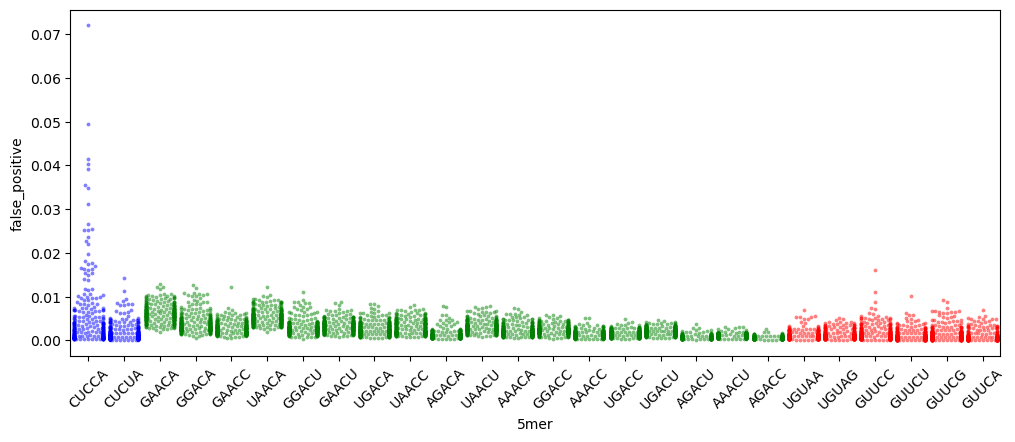

In [80]:
fig, ax = plt.subplots(1)
fig.set_figwidth(12)
fig.set_figheight(4.5)
sns.swarmplot(data=sub_df_ctcya, x="5mer", y="false_positive", alpha=0.5, s=2.75, color='b')
sns.swarmplot(data=sub_df_drach, x="5mer", y="false_positive", alpha=0.5, s=2.75, color='g')
sns.swarmplot(data=sub_df_tgtar, x="5mer", y="false_positive", alpha=0.5, s=2.75, color='r')
sns.swarmplot(data=sub_df_gttcn, x="5mer", y="false_positive", alpha=0.5, s=2.75, color='r')
plt.xticks(rotation=45)
fig.get_figure().savefig(os.path.join(working_dir, "biorelevant_swarmplot.pdf"), dpi=600)